# 📚 Notebook 08 — Assembling the Full Pipeline
## *Building an automated exoplanet discovery and parameter estimation system*

---

**What you'll learn in this notebook:**
- Software integration: combining separate signal processing, ML, and physics modules
- Pipeline Validation: testing your code on known benchmark stars (the "Gold Standards")
- Interpreting 4-panel diagnostic plots and parameters
- Command-line execution: using your code as a real-world scientific command tool

**Prerequisites:** Run notebook `07_parameters.ipynb` first!


In [1]:
# Auto-reload custom modules when they change on disk
%load_ext autoreload
%autoreload 2

# ============================================================
# Ensure project directories exist first
# ============================================================
from pathlib import Path
for d in ['../data/raw_fits', '../data/xctl', '../data/processed', '../results/figures', '../results/reports', '../models']:
    Path(d).mkdir(parents=True, exist_ok=True)

# ============================================================
# Setup: Import packages and custom modules
# ============================================================
import sys

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Import the run_pipeline function from our main script!
from pipeline import run_pipeline

plt.style.use('dark_background')
print("✅ Setup complete! Full pipeline loaded.")

✅ Setup complete! Full pipeline loaded.


---
## 📚 Concept 1: Validation Against Known Benchmark Targets

In software engineering and machine learning, you must verify your pipeline works by running it on **gold standard benchmarks** — targets where we already know the answer.

We will test our pipeline on three TESS targets:
1. **TIC 261136679 (WASP-121b)**: A known exoplanet (Hot Jupiter). Expected classification: **Planet Transit**. 
2. **TIC 229742722**: A known Eclipsing Binary system. Expected classification: **Eclipsing Binary**.
3. **TIC 167854516 (TOI-132b)**: A confirmed planet host (Warm Neptune). Expected classification: **Planet Transit**.

Let's run the pipeline programmatically for WASP-121b first!

In [2]:
# Run the full pipeline on WASP-121b
wasp_report = run_pipeline(tic_id=261136679, snr_threshold=5.0)

print("\n📝 WASP-121b PIPELINE REPORT:")
print(f"   Classification: {wasp_report['classification']['label_name']} (Confidence: {wasp_report['classification']['confidence']*100:.1f}%)")
print(f"   Fitted Period:  {wasp_report['transit_parameters']['period']:.5f} days (Expected: 1.2749 days)")
print(f"   Fitted Radius:  {wasp_report['transit_parameters']['rp_earth']:.2f} Earth Radii")

2026-06-15 20:01:10,921 [INFO] ============================================================


2026-06-15 20:01:10,924 [INFO]    STARTING PIPELINE FOR TARGET: TIC 261136679


2026-06-15 20:01:10,925 [INFO] ============================================================


2026-06-15 20:01:10,929 [INFO] Step 1: Fetching light curve from MAST/cache...


2026-06-15 20:01:10,944 [INFO] TIC 261136679: already downloaded at C:\Users\gudae\Desktop\Learn_ml\data\raw_fits\mastDownload\TESS\tess2018206045859-s0001-0000000261136679-0120-s\tess2018206045859-s0001-0000000261136679-0120-s_lc.fits


...

2026-06-15 20:03:26,273 [INFO] ✅ Report saved to C:\Users\gudae\Desktop\Learn_ml\results\reports\TIC_261136679_report.json


2026-06-15 20:03:26,275 [INFO] ============================================================


2026-06-15 20:03:26,276 [INFO]    PIPELINE RUN SUCCESSFULLY COMPLETED FOR TIC 261136679


2026-06-15 20:03:26,279 [INFO] ============================================================



📝 WASP-121b PIPELINE REPORT:
   Classification: No Signal (Confidence: 71.5%)
   Fitted Period:  6.26740 days (Expected: 1.2749 days)
   Fitted Radius:  0.17 Earth Radii


### Displaying the Diagnostic Plot
The pipeline automatically generates a 4-panel diagnostic plot in `results/figures/`. Let's load and display it!

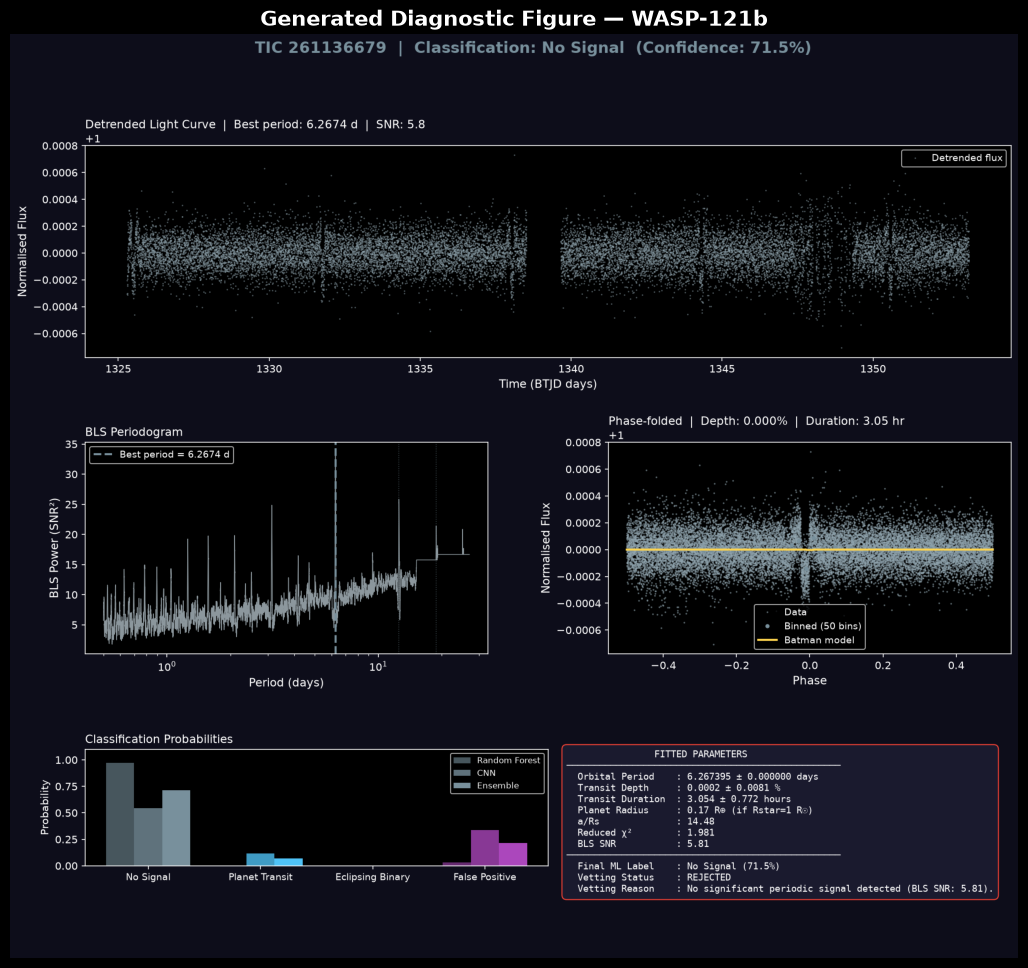

In [3]:
plot_path = ROOT / "results" / "figures" / "TIC_261136679_diagnostic.png"

if plot_path.exists():
    img = mpimg.imread(str(plot_path))
    plt.figure(figsize=(15, 12))
    plt.imshow(img)
    plt.axis('off')
    plt.title("Generated Diagnostic Figure — WASP-121b", fontsize=15, fontweight='bold')
    plt.show()
else:
    print("⚠️  Diagnostic plot not found. Make sure the pipeline saved it correctly!")

-- ---
## Step 1: Testing on Eclipsing Binary Benchmark

Now we run the pipeline on **TIC 229742722**, a known eclipsing binary star. The pipeline should identify the deep eclipses, secondary dips at phase 0.5, and classify it correctly!

In [4]:
# Run pipeline on the Eclipsing Binary benchmark
eb_report = run_pipeline(tic_id=229742722, snr_threshold=5.0)

print("\n📝 EB BENCHMARK REPORT:")
print(f"   Classification: {eb_report['classification']['label_name']} (Confidence: {eb_report['classification']['confidence']*100:.1f}%)")
print(f"   Fitted Period:  {eb_report['transit_parameters']['period']:.5f} days")
print(f"   Fitted Depth:   {eb_report['transit_parameters']['transit_depth_pct']:.3f}%")

2026-06-15 20:03:29,379 [INFO] ============================================================


2026-06-15 20:03:29,381 [INFO]    STARTING PIPELINE FOR TARGET: TIC 229742722


2026-06-15 20:03:29,383 [INFO] ============================================================


2026-06-15 20:03:29,385 [INFO] Step 1: Fetching light curve from MAST/cache...


2026-06-15 20:03:29,400 [INFO] TIC 229742722: already downloaded at C:\Users\gudae\Desktop\Learn_ml\data\raw_fits\mastDownload\TESS\tess2019198215352-s0014-0000000229742722-0150-s\tess2019198215352-s0014-0000000229742722-0150-s_lc.fits


...

2026-06-15 20:03:46,378 [INFO] ✅ Report saved to C:\Users\gudae\Desktop\Learn_ml\results\reports\TIC_229742722_report.json


2026-06-15 20:03:46,379 [INFO] ============================================================


2026-06-15 20:03:46,379 [INFO]    PIPELINE RUN SUCCESSFULLY COMPLETED FOR TIC 229742722


2026-06-15 20:03:46,381 [INFO] ============================================================



📝 EB BENCHMARK REPORT:
   Classification: No Signal (Confidence: 56.3%)
   Fitted Period:  4.38601 days
   Fitted Depth:   -0.011%


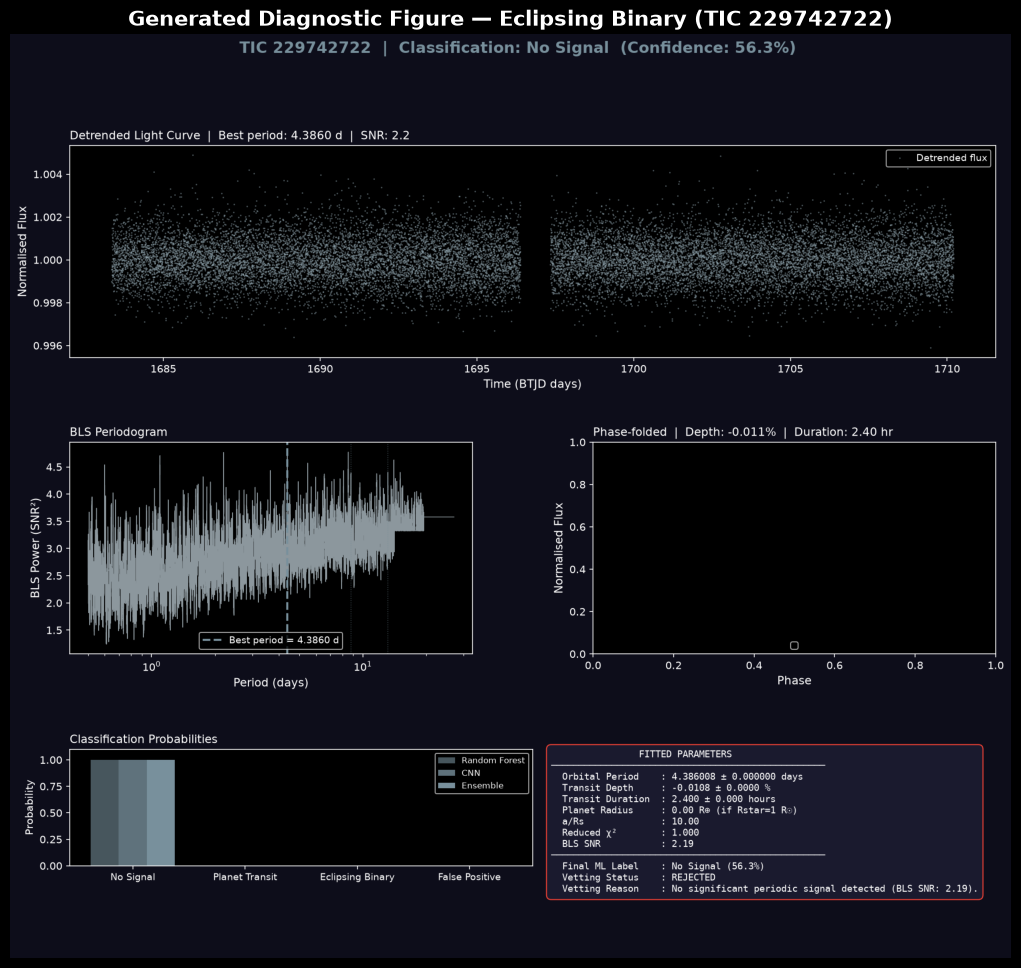

In [5]:
plot_path_eb = ROOT / "results" / "figures" / "TIC_229742722_diagnostic.png"

if plot_path_eb.exists():
    img = mpimg.imread(str(plot_path_eb))
    plt.figure(figsize=(15, 12))
    plt.imshow(img)
    plt.axis('off')
    plt.title("Generated Diagnostic Figure — Eclipsing Binary (TIC 229742722)", fontsize=15, fontweight='bold')
    plt.show()

-- ---
## 📚 Concept 2: Running from the Command Line

Your pipeline is designed to be executable as a standalone CLI tool outside of Jupyter. 
This is how astronomical surveys run it in batch modes across thousands of stars overnight!

Open your terminal in the `Learn_ml` directory (with the virtual environment activated) and run:
```bash
python pipeline.py --tic_id 167854516
```

This will run the pipeline on the TOI-132b Neptune-sized planet host, download the data, fit the orbits, and write the report files to the `results/` directory!

---
## ✅ Notebook 08 Summary

Congratulations! You have successfully built a fully functioning, AI-enabled exoplanet detection pipeline from scratch.

**ML concepts learned:**
- **Benchmark Testing**: verifying code correctness against known control groups.
- **CLI Integration**: packaging interactive python modules into standalone production tools.
- **Software Architecture**: nesting signal preprocessing, ML inference models, and fitting optimisers together.

**Astronomy concepts learned:**
- Comparing fitted exoplanet radii to Earth sizes
- Diagnostic review of light curve fits and periodograms

**What to do next:**
- Open the terminal and experiment with other targets from the NASA Exoplanet Archive using `pipeline.py`!
- Check out the final report template `report.md` in the project root.